In [50]:
import pandas as pd

df= pd.read_csv("SampleSuperstore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [51]:
df.shape

(9994, 13)

In [4]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [7]:
df.info

<bound method DataFrame.info of            Ship Mode    Segment        Country             City       State  \
0       Second Class   Consumer  United States        Henderson    Kentucky   
1       Second Class   Consumer  United States        Henderson    Kentucky   
2       Second Class  Corporate  United States      Los Angeles  California   
3     Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4     Standard Class   Consumer  United States  Fort Lauderdale     Florida   
...              ...        ...            ...              ...         ...   
9989    Second Class   Consumer  United States            Miami     Florida   
9990  Standard Class   Consumer  United States       Costa Mesa  California   
9991  Standard Class   Consumer  United States       Costa Mesa  California   
9992  Standard Class   Consumer  United States       Costa Mesa  California   
9993    Second Class   Consumer  United States      Westminster  California   

      Postal Code R

In [5]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [8]:
df.duplicated().sum()

17

In [11]:
df=df.drop_duplicates()

In [12]:
df.duplicated().sum()

0

In [14]:
df.shape

(9977, 13)

In [15]:
df["Sales"].sum()

2296195.5903

In [16]:
df["Profit"].sum()

286241.4226

In [17]:
df["Sales"].mean()

230.14890150345792

In [ ]:
#Which prooducts sell the most?

In [18]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64

In [19]:
#Which category makes the most profit?

In [20]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122364.6608
Furniture           18421.8137
Name: Profit, dtype: float64

In [21]:
#Which region performs best?

In [22]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       725255.6365
East       678435.1960
Central    500782.8528
South      391721.9050
Name: Sales, dtype: float64

In [23]:
#Which sub-category loses money?

In [30]:
df.groupby(["Category","Sub-Category"])["Profit"].sum().reset_index().sort_values("Profit")

,Category,Sub-Category,Profit
3,Furniture,Tables,-17725.4811
0,Furniture,Bookcases,-3472.5560
12,Office Supplies,Supplies,-1189.0995
8,Office Supplies,Fasteners,949.5182
15,Technology,Machines,3384.7569
9,Office Supplies,Labels,5526.3820
5,Office Supplies,Art,6524.6118
7,Office Supplies,Envelopes,6964.1767
2,Furniture,Furnishings,13052.7230
4,Office Supplies,Appliances,18138.0054


In [31]:
#Average discount by category

In [34]:
df.groupby("Category")["Discount"].mean().reset_index()

,Category,Discount
0,Furniture,0.174027
1,Office Supplies,0.157385
2,Technology,0.132323


In [40]:
import matplotlib.pyplot as plt

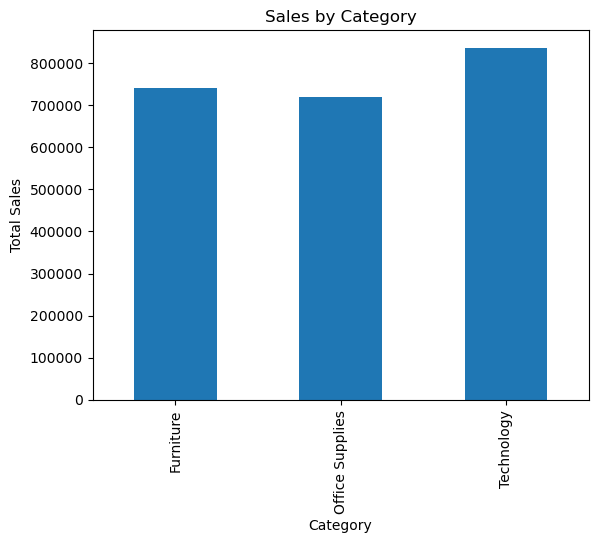

In [42]:
df.groupby("Category")["Sales"].sum().plot(kind="bar")

plt.title("Sales by Category")
plt.ylabel("Total Sales")
plt.show()

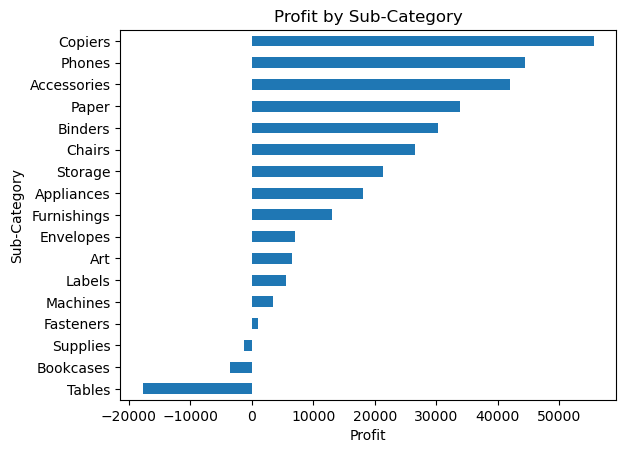

In [39]:
profit_subcat=df.groupby("Sub-Category")["Profit"].sum().sort_values()
profit_subcat.plot(kind="barh")

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")
plt.show()

<Axes: xlabel='Discount', ylabel='Profit'>

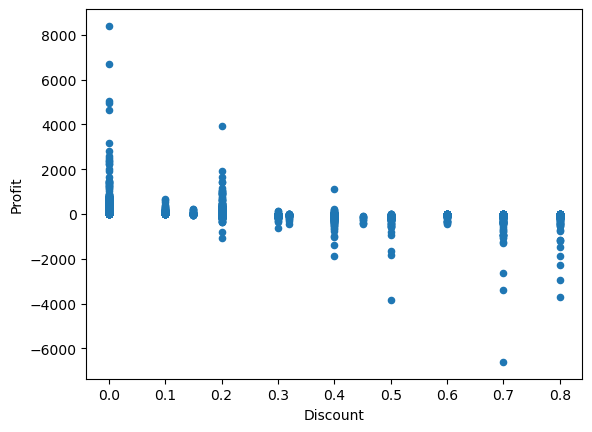

In [43]:
df.plot.scatter(x="Discount",y="Profit")

In [44]:
#which custtomer type spends the most

In [45]:
df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

Segment
Consumer       1.160833e+06
Corporate      7.060701e+05
Home Office    4.292927e+05
Name: Sales, dtype: float64

In [46]:
df

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [49]:
df.to_csv("clean_superstore.csv",index=False)